In [2]:
import pandas as pd


In [3]:
import os
os.listdir("../data")

['dim_customer.csv',
 'dim_delivery_partner_.csv',
 'dim_menu_item.csv',
 'dim_restaurant.csv',
 'fact_delivery_performance.csv',
 'fact_orders.csv',
 'fact_order_items.csv',
 'fact_ratings.csv']

In [4]:
customers =pd.read_csv("../data/dim_customer.csv")
delivery_partners = pd.read_csv("../data/dim_delivery_partner_.csv")
menu_items = pd.read_csv("../data/dim_menu_item.csv")
restaurants = pd.read_csv("../data/dim_restaurant.csv")

order = pd.read_csv("../data/fact_orders.csv")
delivery = pd.read_csv('../data/fact_delivery_performance.csv')
ratings = pd.read_csv('../data/fact_ratings.csv')

# Merge all the main tables 
first join orders + delivery performance 

In [5]:
orders_delivery = order.merge(delivery, on="order_id", how="left")

now we are joiing rating with that 

In [6]:
orders_delivery_ratings = orders_delivery.merge(ratings, on="order_id", how="left")

Now we are adding customer information

In [7]:
print(orders_delivery_ratings.columns.tolist)
print(customers.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['order_id', 'customer_id_x', 'restaurant_id_x', 'delivery_partner_id',
       'order_timestamp', 'subtotal_amount', 'discount_amount', 'delivery_fee',
       'total_amount', 'is_cod', 'is_cancelled', 'actual_delivery_time_mins',
       'expected_delivery_time_mins', 'distance_km', 'customer_id_y',
       'restaurant_id_y', 'rating', 'review_text', 'review_timestamp',
       'sentiment_score'],
      dtype='object')>
<bound method IndexOpsMixin.tolist of Index(['customer_id', 'signup_date', 'city', 'acquisition_channel',
       'Unnamed: 4'],
      dtype='object')>


In [8]:
#orders_delivery_ratings = orders_delivery_ratings.drop(columns=["customer_id_y","restaurant_id_y"])
orders_delivery_ratings = orders_delivery_ratings.rename(columns={
    "customer_id_x":"customer_id",
    "restaurant_id_x":"restaurant_id"
})

In [9]:
data = orders_delivery_ratings.merge(customers, on="customer_id", how="left")

In [10]:
print(data.columns.tolist())

['order_id', 'customer_id', 'restaurant_id', 'delivery_partner_id', 'order_timestamp', 'subtotal_amount', 'discount_amount', 'delivery_fee', 'total_amount', 'is_cod', 'is_cancelled', 'actual_delivery_time_mins', 'expected_delivery_time_mins', 'distance_km', 'customer_id_y', 'restaurant_id_y', 'rating', 'review_text', 'review_timestamp', 'sentiment_score', 'signup_date', 'city', 'acquisition_channel', 'Unnamed: 4']


Now add restaurant information 

In [11]:
data = data.merge(restaurants, on="restaurant_id", how="left")

Add delivery partner info 

In [12]:
data = data.merge(delivery_partners, on="delivery_partner_id", how="left")

# Now we have one final dataset for analysis 
create crisis phase column

In [13]:
data['order_timestamp'] = pd.to_datetime(data['order_timestamp'])

data['phase'] = data['order_timestamp'].apply(lambda x: 'Pre-Crisis' if x.month <= 5 else 'Crisis')

Let's Prepare final dataset property

In [14]:
data['order_timestamp'] = pd.to_datetime(data['order_timestamp'])
data['month'] = data['order_timestamp'].dt.to_period('M').astype(str)
data['year'] = data['order_timestamp'].dt.year
data['month_num'] = data['order_timestamp'].dt.month

Fix the phase column a little better

In [15]:
data['phase'] = data['month_num'].apply(
    lambda x: 'Pre-Crisis' if x <= 5 else 'Crisis'
)

# Now data cleaning first 

In [16]:
data.shape

(149166, 40)

In [17]:
data.isnull().sum()

order_id                            0
customer_id                         0
restaurant_id                       0
delivery_partner_id              5635
order_timestamp                     0
subtotal_amount                     0
discount_amount                     0
delivery_fee                        0
total_amount                        0
is_cod                              0
is_cancelled                        0
actual_delivery_time_mins           0
expected_delivery_time_mins         0
distance_km                         0
customer_id_y                   80341
restaurant_id_y                 80341
rating                          80341
review_text                     80341
review_timestamp                80341
sentiment_score                 80341
signup_date                      5053
city_x                           5053
acquisition_channel              5053
Unnamed: 4                     149166
restaurant_name                     0
city_y                              0
cuisine_type

In [18]:
(data.isnull().sum() / len(data)) * 100

order_id                         0.000000
customer_id                      0.000000
restaurant_id                    0.000000
delivery_partner_id              3.777671
order_timestamp                  0.000000
subtotal_amount                  0.000000
discount_amount                  0.000000
delivery_fee                     0.000000
total_amount                     0.000000
is_cod                           0.000000
is_cancelled                     0.000000
actual_delivery_time_mins        0.000000
expected_delivery_time_mins      0.000000
distance_km                      0.000000
customer_id_y                   53.860129
restaurant_id_y                 53.860129
rating                          53.860129
review_text                     53.860129
review_timestamp                53.860129
sentiment_score                 53.860129
signup_date                      3.387501
city_x                           3.387501
acquisition_channel              3.387501
Unnamed: 4                     100

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 40 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_id                     149166 non-null  object        
 1   customer_id                  149166 non-null  object        
 2   restaurant_id                149166 non-null  object        
 3   delivery_partner_id          143531 non-null  object        
 4   order_timestamp              149166 non-null  datetime64[ns]
 5   subtotal_amount              149166 non-null  float64       
 6   discount_amount              149166 non-null  float64       
 7   delivery_fee                 149166 non-null  float64       
 8   total_amount                 149166 non-null  float64       
 9   is_cod                       149166 non-null  object        
 10  is_cancelled                 149166 non-null  object        
 11  actual_delivery_time_mins 

In [20]:
data.duplicated().sum()

np.int64(0)

In [21]:
data = data.drop_duplicates()

Proper cleaning steps we should follow
Step 1 — Drop fully useless columns

In [22]:
data = data.drop(columns=['Unnamed: 4'], errors='ignore')

Step 2 — Rename confusing columns

In [23]:
data = data.rename(columns={
    'city_x':'customer_city',
    'city_y': 'restaurants_city',
    'city' : 'partner_city',
    'is_active_x' : 'restaurant_is_active',
    'is_active_y' : 'partner_is_active'
})

In [24]:
object_cols = data.select_dtypes(include='object').columns

for col in object_cols:
    print(f"\nColumn: {col}")
    print(data[col].dropna().unique()[:10])


Column: order_id
['ORD202501023439' 'ORD202501012051' 'ORD202501019281' 'ORD202501000124'
 'ORD202501006518' 'ORD202501018255' 'ORD202501004299' 'ORD202501018036'
 'ORD202501009329' 'ORD202501007498']

Column: customer_id
['CUST181110' 'CUST025572' 'CUST179306' 'CUST191820' 'CUST033760'
 'CUST011850' 'CUST107475' 'CUST093042' 'CUST104825' 'CUST135654']

Column: restaurant_id
['REST08622' 'REST02383' 'REST14069' 'REST19745' 'REST12962' 'REST01307'
 'REST12542' 'REST13907' 'REST10267' 'REST05434']

Column: delivery_partner_id
['DP05541' 'DP08091' 'DP02021' 'DP13859' 'DP09615' 'DP14063' 'DP07728'
 'DP01276' 'DP03078' 'DP11625']

Column: is_cod
['N' 'Y']

Column: is_cancelled
['N' 'Y']

Column: customer_id_y
['CUST181110' 'CUST179306' 'CUST093042' 'CUST110825' 'CUST181669'
 'CUST024044' 'CUST139611' 'CUST078091' 'CUST035317' 'CUST092566']

Column: restaurant_id_y
['REST08622' 'REST14069' 'REST13907' 'REST08451' 'REST00225' 'REST16733'
 'REST13916' 'REST12102' 'REST03046' 'REST01441']

Col

Step 4 — Fix Boolean Columns

In [25]:
clean_data = data.copy()

In [26]:
clean_data['is_cod'] = clean_data['is_cod'].map({'Y':1,'N':0})
clean_data['is_cancelled'] = clean_data['is_cancelled'].map({'Y':1,'N':0})
clean_data['restaurant_is_active'] = clean_data['restaurant_is_active'].map({'Y':1,'N':0})
clean_data['partner_is_active'] = clean_data['partner_is_active'].map({'Y':1,'N':0})

In [27]:
clean_data['signup_data'] = pd.to_datetime(clean_data['signup_date'],dayfirst=True, errors='coerce')
clean_data['review_timestamp'] = pd.to_datetime(clean_data['review_timestamp'], dayfirst=True,errors='coerce')

In [28]:
clean_data['review_text'] = clean_data['review_text'].fillna('No Review')
clean_data['rating'] = clean_data['rating'].fillna(0)
clean_data['sentiment_score'] = clean_data['sentiment_score'].fillna(0)

In [29]:
clean_data['customer_city'] = clean_data['customer_city'].fillna('Unknown')
clean_data['acquisition_channel'] = clean_data['acquisition_channel'].fillna('Unknown')

In [30]:
clean_data['partner_name'] = clean_data['partner_name'].fillna('Unknown')
clean_data['partner_city'] = clean_data['partner_city'].fillna('Unknown')
clean_data['vehicle_type'] = clean_data['vehicle_type'].fillna('Unknown')
clean_data['employment_type'] = clean_data['employment_type'].fillna('Unknown')
clean_data['avg_rating'] = clean_data['avg_rating'].fillna(0)
clean_data['partner_is_active'] = clean_data['partner_is_active'].fillna(0)

In [31]:
clean_data['avg_prep_time_min'] = clean_data['avg_prep_time_min'].astype('category')

In [32]:
clean_data = clean_data.drop(columns=['restaurant_name'])

In [33]:
clean_data.isnull().sum()

order_id                           0
customer_id                        0
restaurant_id                      0
delivery_partner_id             5635
order_timestamp                    0
subtotal_amount                    0
discount_amount                    0
delivery_fee                       0
total_amount                       0
is_cod                             0
is_cancelled                       0
actual_delivery_time_mins          0
expected_delivery_time_mins        0
distance_km                        0
customer_id_y                  80341
restaurant_id_y                80341
rating                             0
review_text                        0
review_timestamp               80341
sentiment_score                    0
signup_date                     5053
customer_city                      0
acquisition_channel                0
restaurants_city                   0
cuisine_type                       0
partner_type                       0
avg_prep_time_min                  0
r

In [34]:
clean_data.duplicated().sum()
clean_data['order_id'].duplicated().sum()

np.int64(0)

In [35]:
clean_data['is_cod'] = clean_data['is_cod'].str.strip().map({'Y':1, 'N':0})

AttributeError: Can only use .str accessor with string values!

In [ ]:
clean_data['is_cod'].unique()

array([nan])

In [ ]:
clean_data['is_cod'] = data['is_cod'].map({'Y':1, 'N':0})

In [ ]:
clean_data['is_cod'].value_counts()

is_cod
0    102351
1     46815
Name: count, dtype: int64

In [ ]:
clean_data.isnull().sum()

order_id                           0
customer_id                        0
restaurant_id                      0
delivery_partner_id             5635
order_timestamp                    0
subtotal_amount                    0
discount_amount                    0
delivery_fee                       0
total_amount                       0
is_cod                             0
is_cancelled                       0
actual_delivery_time_mins          0
expected_delivery_time_mins        0
distance_km                        0
rating                             0
review_text                        0
review_timestamp               80341
sentiment_score                    0
signup_date                     5053
customer_city                      0
acquisition_channel                0
restaurants_city                   0
cuisine_type                       0
partner_type                       0
avg_prep_time_min                  0
restaurant_is_active               0
partner_name                       0
p

In [ ]:
clean_data = clean_data.drop(columns=['signup_data'], errors='ignore')

In [ ]:
clean_data.isnull().sum()

order_id                           0
customer_id                        0
restaurant_id                      0
delivery_partner_id             5635
order_timestamp                    0
subtotal_amount                    0
discount_amount                    0
delivery_fee                       0
total_amount                       0
is_cod                             0
is_cancelled                       0
actual_delivery_time_mins          0
expected_delivery_time_mins        0
distance_km                        0
rating                             0
review_text                        0
review_timestamp               80341
sentiment_score                    0
signup_date                     5053
customer_city                      0
acquisition_channel                0
restaurants_city                   0
cuisine_type                       0
partner_type                       0
avg_prep_time_min                  0
restaurant_is_active               0
partner_name                       0
p

# save the clean dataset

In [67]:
clean_data.to_csv("clean_food_delivery_data.csv", index=False)
clean_data.head(5)
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149166 entries, 0 to 149165
Data columns (total 39 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_id                     149166 non-null  object        
 1   customer_id                  149166 non-null  object        
 2   restaurant_id                149166 non-null  object        
 3   delivery_partner_id          143531 non-null  object        
 4   order_timestamp              149166 non-null  datetime64[ns]
 5   subtotal_amount              149166 non-null  float64       
 6   discount_amount              149166 non-null  float64       
 7   delivery_fee                 149166 non-null  float64       
 8   total_amount                 149166 non-null  float64       
 9   is_cod                       149166 non-null  int64         
 10  is_cancelled                 149166 non-null  int64         
 11  actual_delivery_time_mins 

# Question 1 : Monthly Order
compare total order across pre-crisis vs crisis 

In [ ]:
clean_data[['month','order_id']].groupby('month').count()

,order_id
month,
2025-01,23539
2025-02,22667
2025-03,23543
2025-04,21466
2025-05,22591
2025-06,9293
2025-07,8818
2025-08,8555
2025-09,8694


# Split Pre-crisi vs crisis

In [44]:
pre_crisis = clean_data[clean_data['phase'] == 'Pre-Crisis']['order_id'].count()
crisis = clean_data[clean_data['phase'] == 'Crisis']['order_id'].count()

pre_crisis,crisis

(np.int64(113806), np.int64(35360))

calculate the decline

In [45]:
decline_pct = ((pre_crisis - crisis ) / pre_crisis ) * 100
decline_pct

np.float64(68.92958192010965)

Monthly trend table

In [48]:
monthly_avg = clean_data.groupby('phase')['order_id'].count() / clean_data.groupby('phase')['month'].nunique()
monthly_avg

phase
Crisis         8840.0
Pre-Crisis    22761.2
dtype: float64

plot the trend 

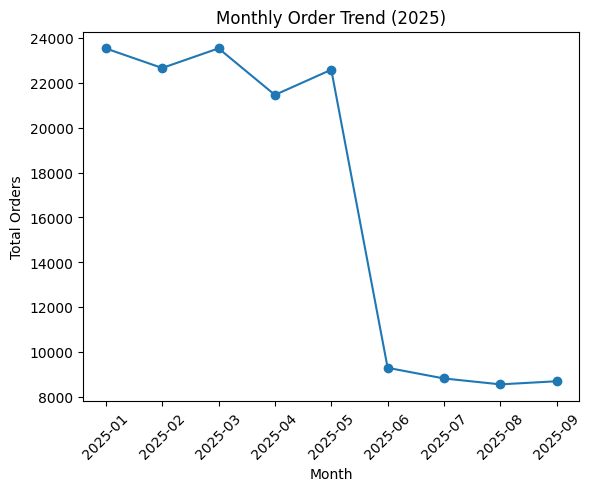

In [51]:
import matplotlib.pyplot as plt

monthly_order = clean_data.groupby('month')['order_id'].count()

monthly_order.plot(kind= 'line', marker= 'o')
plt.title('Monthly Order Trend (2025)')
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.show()

# 2. Question Which top 5 city groups experienced the highest percentage decline in orders during the crisis period compared to the pre-crisis period? 

In [55]:
city_order = clean_data.groupby(['customer_city', 'phase'])['order_id'].count().reset_index()

In [56]:
city_pivot = city_order.pivot(index='customer_city', columns='phase', values='order_id').reset_index()

In [57]:
city_pivot = city_pivot.fillna(0)

In [62]:
city_pivot['decline_pct'] = (
    (city_pivot['Pre-Crisis'] - city_pivot['Crisis']) 
    / city_pivot['Pre-Crisis']
) * 100

In [63]:
city_pivot = city_pivot[city_pivot['Pre-Crisis']>100]

In [64]:
top_decline_cities = city_pivot.sort_values(by='decline_pct',ascending=False).head(5)
top_decline_cities

phase,customer_city,Crisis,Pre-Crisis,decline_pct
1,Bengaluru,9311,31277,70.230521
6,Mumbai,5322,17848,70.181533
0,Ahmedabad,2303,7648,69.887552
7,Pune,2662,8817,69.808325
3,Delhi,4704,15580,69.807445


# question 3 Among restaurants with at least 50 pre-crisis orders, which top 10 high-volume restaurants experienced the largest percentage decline in order counts during  the crisis period? 


In [70]:
restaurant_orders = clean_data.groupby(['restaurant_id', 'phase'])['order_id'].count().reset_index()

In [71]:
restaurant_pivot = restaurant_orders.pivot(index='restaurant_id',columns='phase',values='order_id').reset_index()

In [72]:
restaurant_pivot = restaurant_pivot.fillna(1)

In [73]:
restaurant_pivot = restaurant_pivot[restaurant_pivot['Pre-Crisis'] >= 50]

In [74]:
restaurant_pivot['decline_pct'] = (
    (restaurant_pivot['Pre-Crisis'] - restaurant_pivot['Crisis'])
    / restaurant_pivot['Pre-Crisis']
) * 100

In [77]:
top_restaurants = restaurant_pivot.sort_values(by='decline_pct', ascending=False).head(10)
top_restaurants

phase,restaurant_id,Crisis,Pre-Crisis,decline_pct


In [81]:
top_restaurants = top_restaurants.merge(
    clean_data[['restaurant_id', 'restaurant_name']].drop_duplicates(),
    on='restaurant_id',
    how='left'
)

KeyError: "['restaurant_name'] not in index"

In [ ]:
i 